In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Scikit-learn imports
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [ ]:
data=pd.read_csv("/content/Car_data_jtrjuw.csv")

## 1. Problem Understanding

### Business Problem
An online car marketplace aims to build a machine learning model to accurately estimate the selling price of used cars. This model will help both sellers in pricing their vehicles competitively and buyers in understanding fair market values, thereby enhancing transparency and efficiency in the marketplace.

### Target Variable
The target variable for this regression problem is `Selling_Price`, which represents the price at which a used car was sold.

### Features
The features that will be used to predict the `Selling_Price` include:
- `Car_Name`: The name of the car model.
- `Year`: The year the car was manufactured.
- `Present_Price`: The current showroom price of the car (in Lakhs).
- `Kms_Driven`: The total kilometers driven by the car.
- `Fuel_Type`: The type of fuel the car uses (Petrol, Diesel, CNG).
- `Seller_Type`: Whether the seller is a Dealer or an Individual.
- `Transmission`: The transmission type (Manual or Automatic).
- `Owner`: The number of previous owners the car had.

In [ ]:
display(data.head())

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [ ]:
print('--- DataFrame Info ---')
data.info()

--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [ ]:
print('\n--- Descriptive Statistics ---')
display(data.describe())


--- Descriptive Statistics ---


,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [ ]:
print('\n--- Null Values Count ---')
display(data.isnull().sum())


--- Null Values Count ---


,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


In [ ]:
print('\n--- Last 5 Rows of DataFrame ---')
display(data.tail())


--- Last 5 Rows of DataFrame ---


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


Distribution of Numerical Value

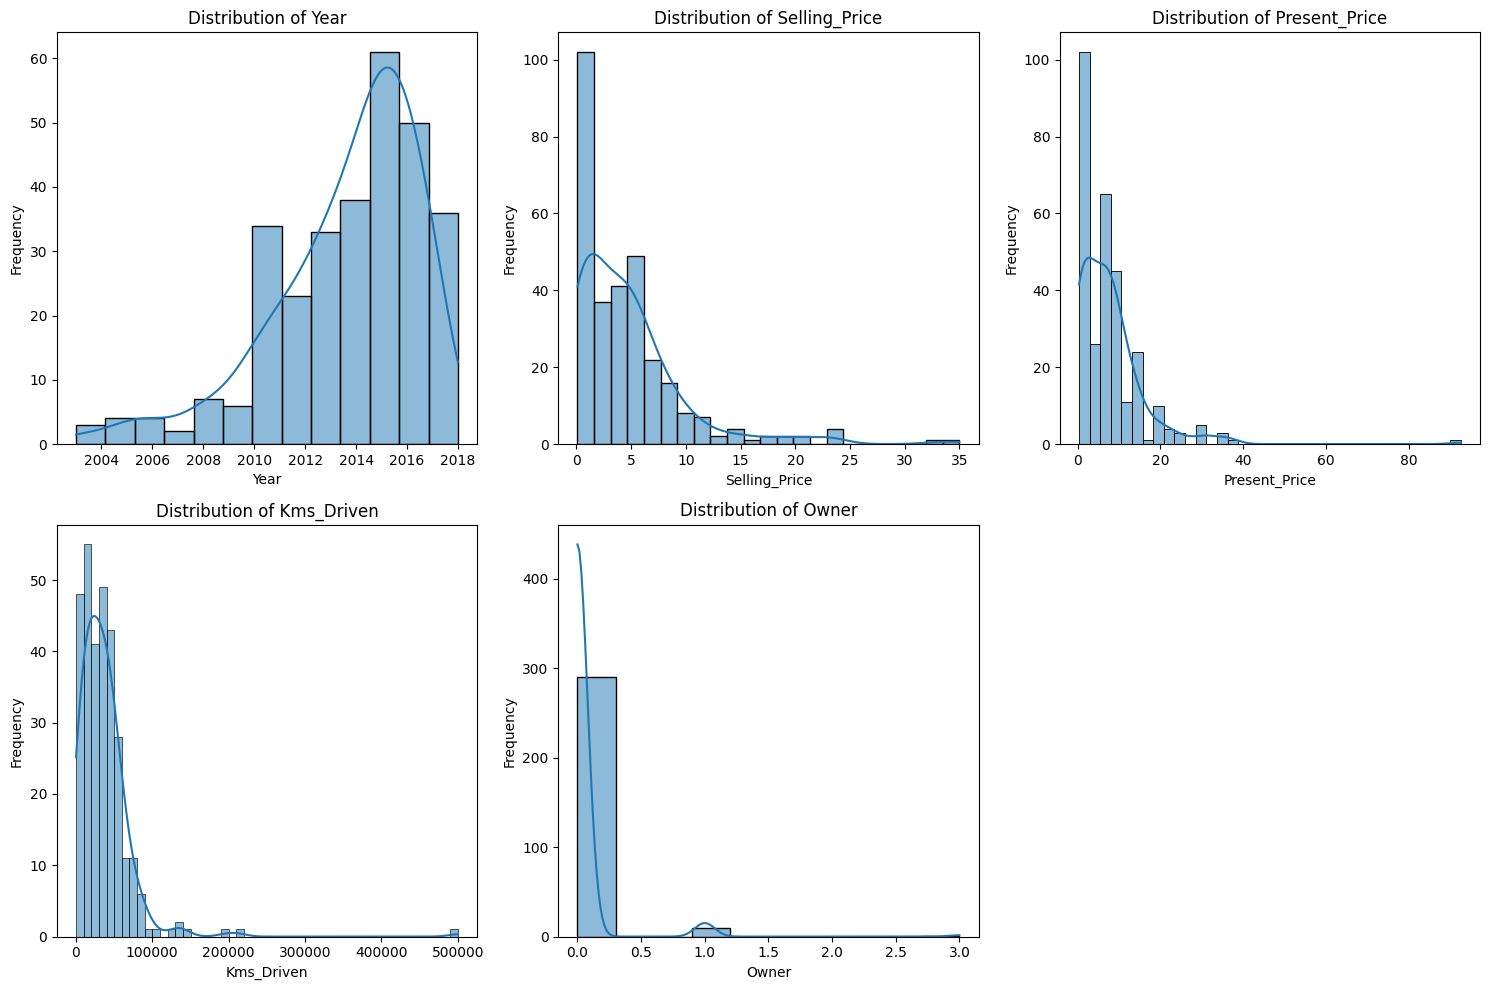

In [ ]:
numerical_cols = ['Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Owner']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1) # Adjust subplot grid as needed, e.g., 2 rows, 3 columns
    sns.histplot(data[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Relationships with Target Variable (Selling Price)

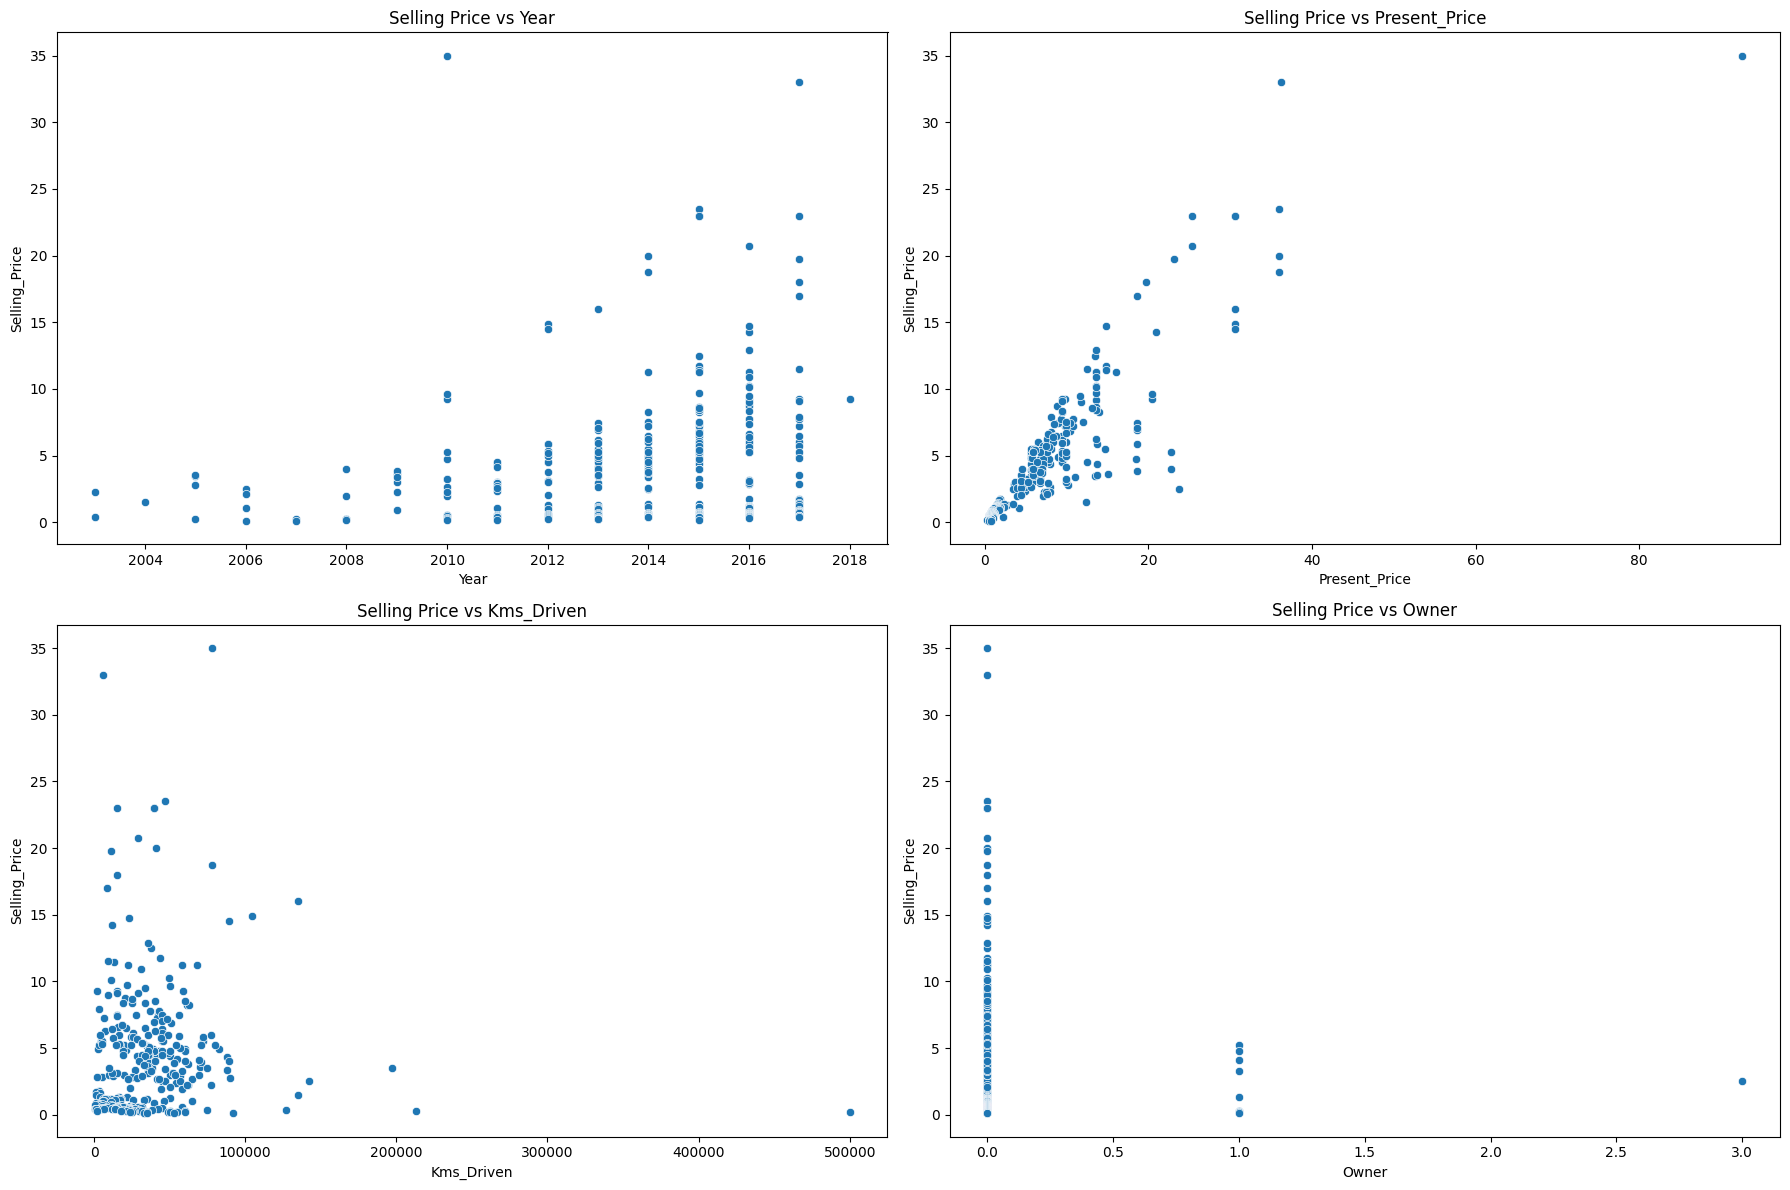

In [ ]:
numerical_features = ['Year', 'Present_Price', 'Kms_Driven', 'Owner']
categorical_features = ['Fuel_Type', 'Seller_Type', 'Transmission']

# Scatter plots for numerical features vs Selling_Price
plt.figure(figsize=(18, 12))
for i, col in enumerate(numerical_features):
    plt.subplot(2, 2, i + 1)
    sns.scatterplot(x=data[col], y=data['Selling_Price'])
    plt.title(f'Selling Price vs {col}')
    plt.xlabel(col)
    plt.ylabel('Selling_Price')
plt.tight_layout()
plt.show()


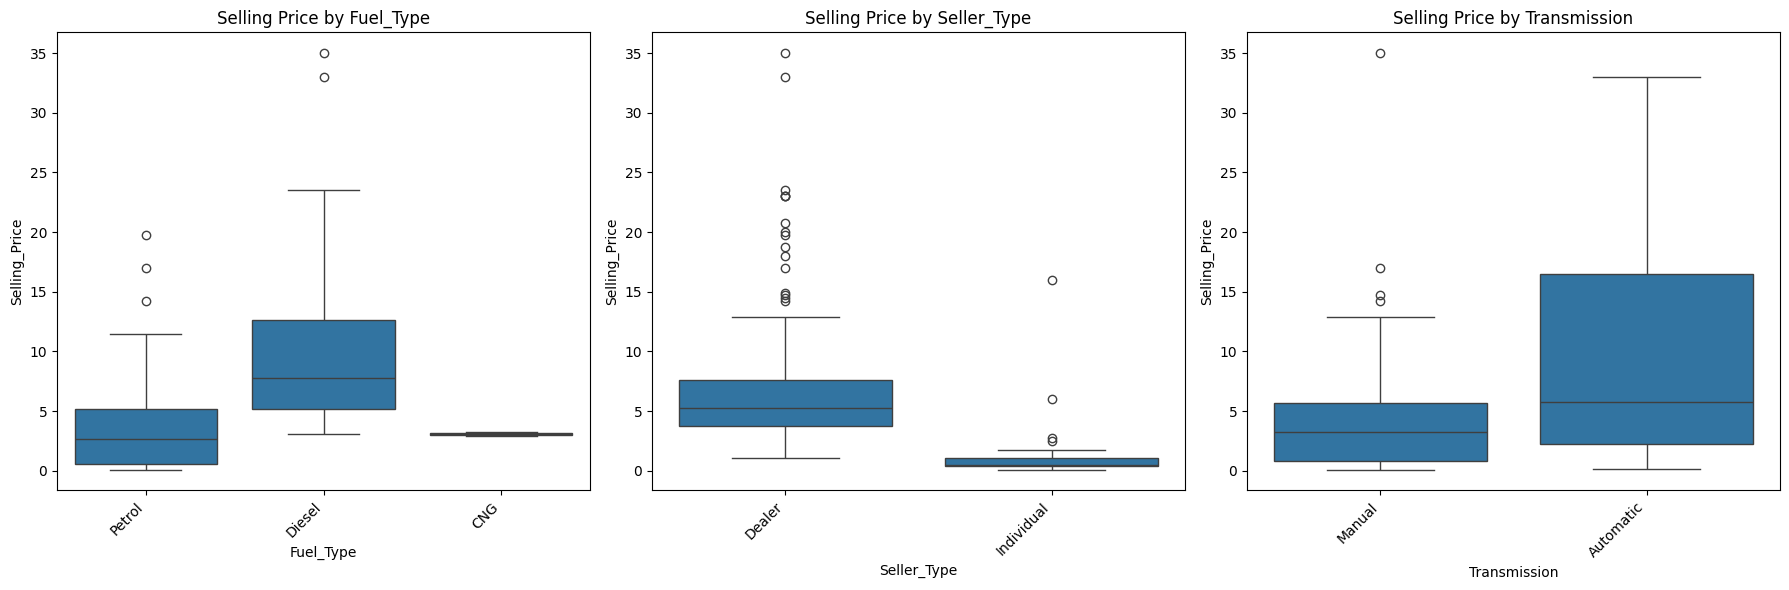

In [ ]:
# Box plots for categorical features vs Selling_Price
plt.figure(figsize=(18, 6))
for i, col in enumerate(categorical_features):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(x=data[col], y=data['Selling_Price'])
    plt.title(f'Selling Price by {col}')
    plt.xlabel(col)
    plt.ylabel('Selling_Price')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


These plots help us understand how each feature impacts the car's selling price:

*   **Year**: Generally, newer cars (higher 'Year' value) tend to have higher 'Selling_Price', as expected.
*   **Present_Price**: There's a strong positive correlation; cars with a higher 'Present_Price' also have a higher 'Selling_Price'.
*   **Kms_Driven**: As 'Kms_Driven' increases, 'Selling_Price' tends to decrease, indicating depreciation with usage.
*   **Owner**: Most cars have 0 owners (first owner), and the selling price generally decreases with an increasing number of owners.
*   **Fuel_Type**: Diesel cars appear to have higher selling prices on average compared to Petrol or CNG cars.
*   **Seller_Type**: Dealer-sold cars generally have higher selling prices than individual-sold cars.
*   **Transmission**: Manual transmission cars seem to have a wider range of selling prices, but automatic cars can also reach high prices.

### Correlation Matrix for Numerical Features

In [ ]:
correlation_matrix = data[numerical_features + ['Selling_Price']].corr()
display(correlation_matrix)


,Year,Present_Price,Kms_Driven,Owner,Selling_Price
Year,1.000000,-0.047584,-0.524342,-0.182104,0.236141
Present_Price,-0.047584,1.000000,0.203647,0.008057,0.878983
Kms_Driven,-0.524342,0.203647,1.000000,0.089216,0.029187
Owner,-0.182104,0.008057,0.089216,1.000000,-0.088344
Selling_Price,0.236141,0.878983,0.029187,-0.088344,1.000000


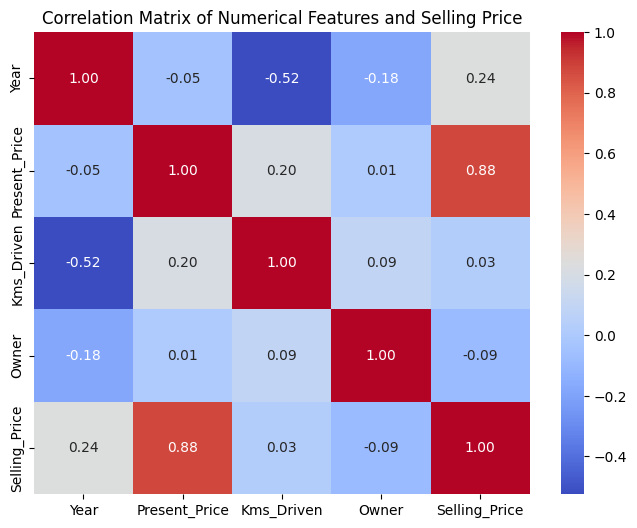

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features and Selling Price')
plt.show()


This heatmap visually confirms the insights from the correlation matrix:
*   Strong positive correlation between `Present_Price` and `Selling_Price`.
*   Moderate positive correlation between `Year` and `Selling_Price`.
*   Weak to negligible correlation for `Kms_Driven` and `Owner` with `Selling_Price`.

### Encoding Categorical Features

In [ ]:
# One-hot encode categorical features
data_encoded = pd.get_dummies(data, columns=categorical_features, drop_first=True)

display(data_encoded.head())


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Owner,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,ritz,2014,3.35,5.59,27000,0,False,True,False,True
1,sx4,2013,4.75,9.54,43000,0,True,False,False,True
2,ciaz,2017,7.25,9.85,6900,0,False,True,False,True
3,wagon r,2011,2.85,4.15,5200,0,False,True,False,True
4,swift,2014,4.60,6.87,42450,0,True,False,False,True


As you can see, the original categorical columns (`Fuel_Type`, `Seller_Type`, `Transmission`) have been replaced by new binary (0 or 1) columns, representing each unique category. `drop_first=True` prevents multicollinearity by dropping one of the generated dummy variables for each feature.


### Splitting Data into Training and Testing Sets

In [ ]:
# Define features (X) and target (y)
X = data_encoded.drop(['Selling_Price', 'Car_Name'], axis=1)
y = data_encoded['Selling_Price']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (240, 8)
X_test shape: (61, 8)
y_train shape: (240,)
y_test shape: (61,)


In [ ]:
# Initialize StandardScaler
scaler = StandardScaler()

# Identify numerical columns for scaling (excluding encoded categorical and target)
numerical_cols_to_scale = ['Year', 'Present_Price', 'Kms_Driven', 'Owner']

# Scale numerical features in X_train
X_train[numerical_cols_to_scale] = scaler.fit_transform(X_train[numerical_cols_to_scale])

# Scale numerical features in X_test using the *same* scaler fitted on X_train
X_test[numerical_cols_to_scale] = scaler.transform(X_test[numerical_cols_to_scale])

print("Numerical features in X_train and X_test scaled successfully.")
display(X_train.head())
display(X_test.head())

Numerical features in X_train and X_test scaled successfully.


,Year,Present_Price,Kms_Driven,Owner,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
184,-1.969861,-0.753596,-0.275555,3.528211,False,True,True,True
132,1.156443,-0.731307,-0.814282,-0.185695,False,True,True,True
194,-1.969861,-0.749472,0.299088,-0.185695,False,True,True,True
75,0.461709,-0.079351,-0.036120,-0.185695,False,True,False,True
111,0.809076,-0.670012,-0.689776,-0.185695,False,True,True,True


,Year,Present_Price,Kms_Driven,Owner,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
177,0.809076,-0.773656,-0.323442,-0.185695,False,True,True,False
289,0.809076,0.678479,-0.635185,-0.185695,False,True,False,True
228,-0.580393,0.210408,0.538523,-0.185695,True,False,False,True
198,-0.927760,-0.773656,-0.060064,3.528211,False,True,True,True
60,-0.233025,1.236821,0.059678,-0.185695,False,True,False,True


The numerical features in `X_train` and `X_test` have been scaled using `StandardScaler`. This step is crucial for many machine learning algorithms, especially those that rely on distance calculations or gradient descent, as it standardizes the range of independent variables. This helps prevent features with larger absolute values from dominating the learning process.

### Initializing the Linear Regression Model

In [ ]:
# Initialize the Linear Regression model
linear_model = LinearRegression()

print("Linear Regression model initialized successfully.")

Linear Regression model initialized successfully.


### Training the Linear Regression Model

In [ ]:
# Train the linear regression model with scaled data
linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully with scaled data.")

Linear Regression model trained successfully with scaled data.


### Performing K-Fold Cross-Validation

In [ ]:
from sklearn.model_selection import KFold, cross_val_score

# Prepare the full scaled dataset for cross-validation
X_scaled = pd.concat([X_train, X_test])
y_full = pd.concat([y_train, y_test])

# Make sure the index aligns correctly after concatenation if not already reset
X_scaled = X_scaled.reset_index(drop=True)
y_full = y_full.reset_index(drop=True)

# Initialize KFold cross-validator
# n_splits: number of folds (e.g., 5, 10)
# shuffle: whether to shuffle the data before splitting into batches
# random_state: ensures reproducibility
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation
# The 'neg_mean_squared_error' scoring calculates MSE, but returns it as a negative value.
# We will convert it to positive for interpretation.
cv_mse_scores = -cross_val_score(linear_model, X_scaled, y_full, cv=kf, scoring='neg_mean_squared_error')
cv_r2_scores = cross_val_score(linear_model, X_scaled, y_full, cv=kf, scoring='r2')

print("Cross-Validation MSE scores for each fold:", cv_mse_scores)
print("Mean CV MSE:", cv_mse_scores.mean())
print("Standard Deviation of CV MSE:", cv_mse_scores.std())

print("\nCross-Validation R2 scores for each fold:", cv_r2_scores)
print("Mean CV R2:", cv_r2_scores.mean())
print("Standard Deviation of CV R2:", cv_r2_scores.std())

Cross-Validation MSE scores for each fold: [2.12488386 8.48923422 2.59215146 4.83861354 3.93328536]
Mean CV MSE: 4.3956336882192995
Standard Deviation of CV MSE: 2.2616991555897954

Cross-Validation R2 scores for each fold: [0.86434635 0.77841761 0.84128816 0.86154514 0.82846811]
Mean CV R2: 0.8348130740052293
Standard Deviation of CV R2: 0.031143061750155826


### Making Predictions and Evaluating the Model

In [ ]:
# Make predictions on the scaled test set
y_pred = linear_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Squared Error (MSE): 3.48
Root Mean Squared Error (RMSE): 1.87
Mean Absolute Error (MAE): 1.22
R-squared (R2): 0.85


### Visualizing Predicted vs. Actual Prices

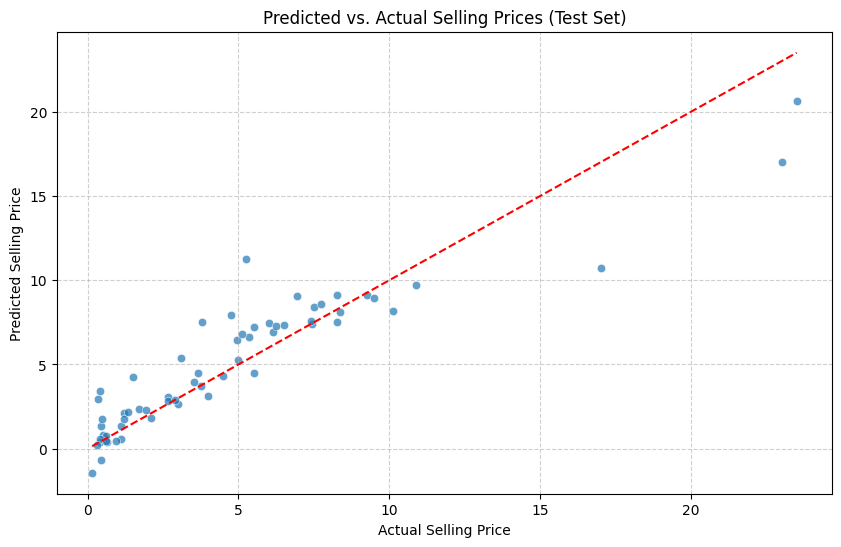

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--') # Perfect prediction line
plt.title('Predicted vs. Actual Selling Prices (Test Set)')
plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Checking for Outliers with Boxplots

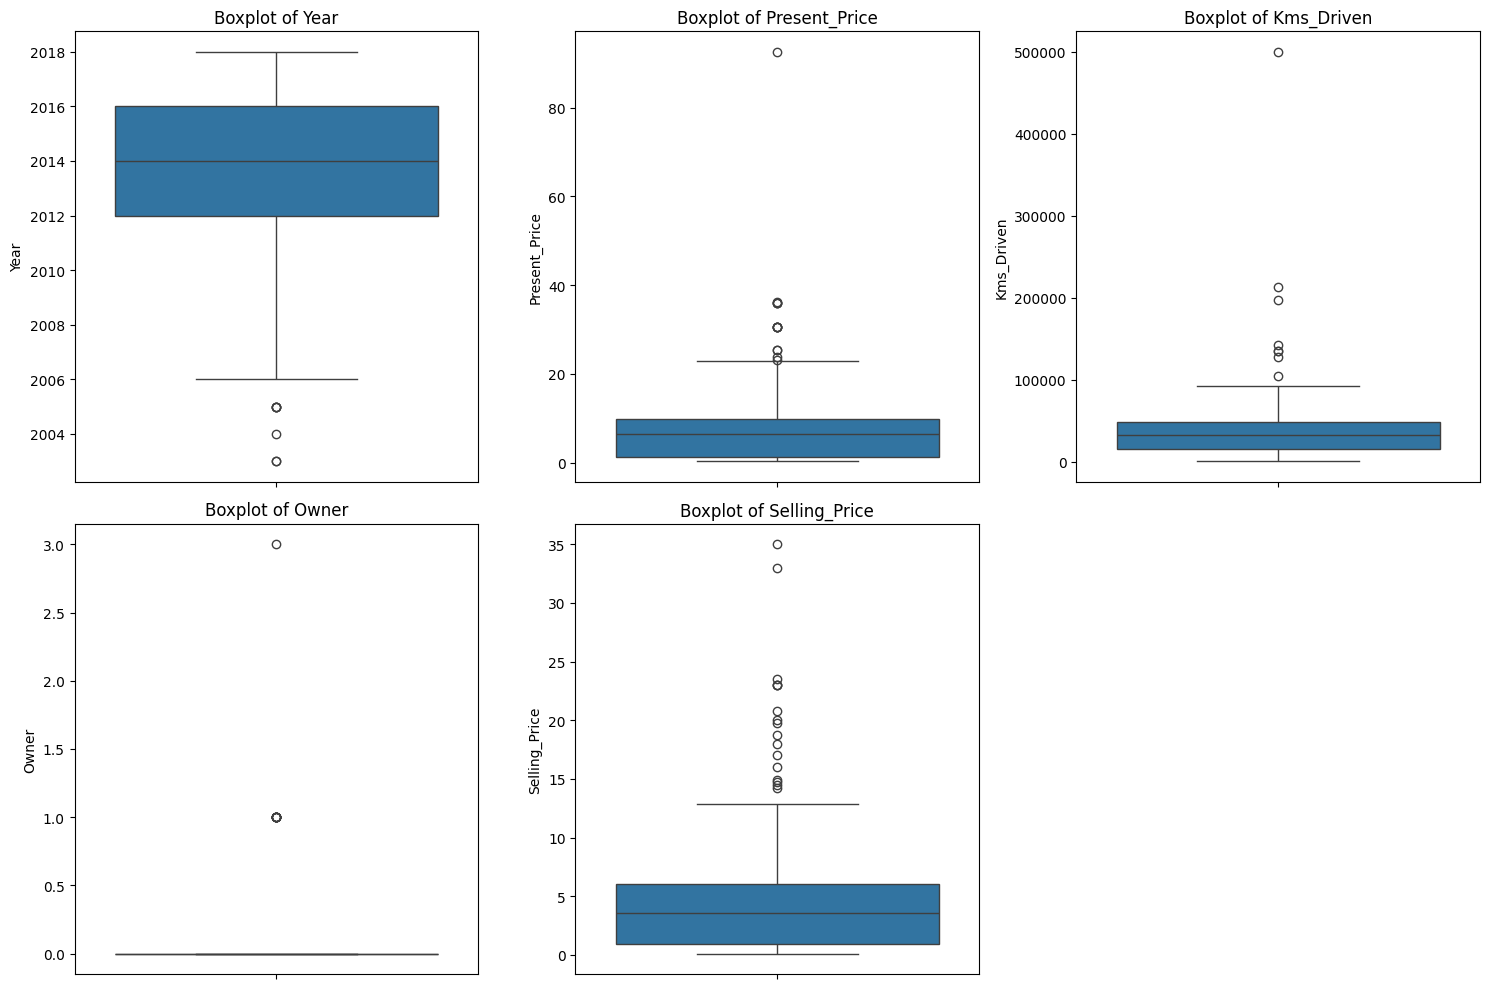

In [ ]:
numerical_features_for_outliers = ['Year', 'Present_Price', 'Kms_Driven', 'Owner', 'Selling_Price']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_features_for_outliers):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=data[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

### Feature Scaling and Cross-Validation

### Feature Importance Analysis

Feature Importances (sorted by absolute coefficient):


,Feature,Coefficient,Absolute_Coefficient
1,Present_Price,3.850784,3.850784
4,Fuel_Type_Diesel,2.533273,2.533273
7,Transmission_Manual,-1.639022,1.639022
6,Seller_Type_Individual,-1.190593,1.190593
0,Year,1.018523,1.018523
5,Fuel_Type_Petrol,0.738464,0.738464
2,Kms_Driven,-0.257158,0.257158
3,Owner,-0.243345,0.243345


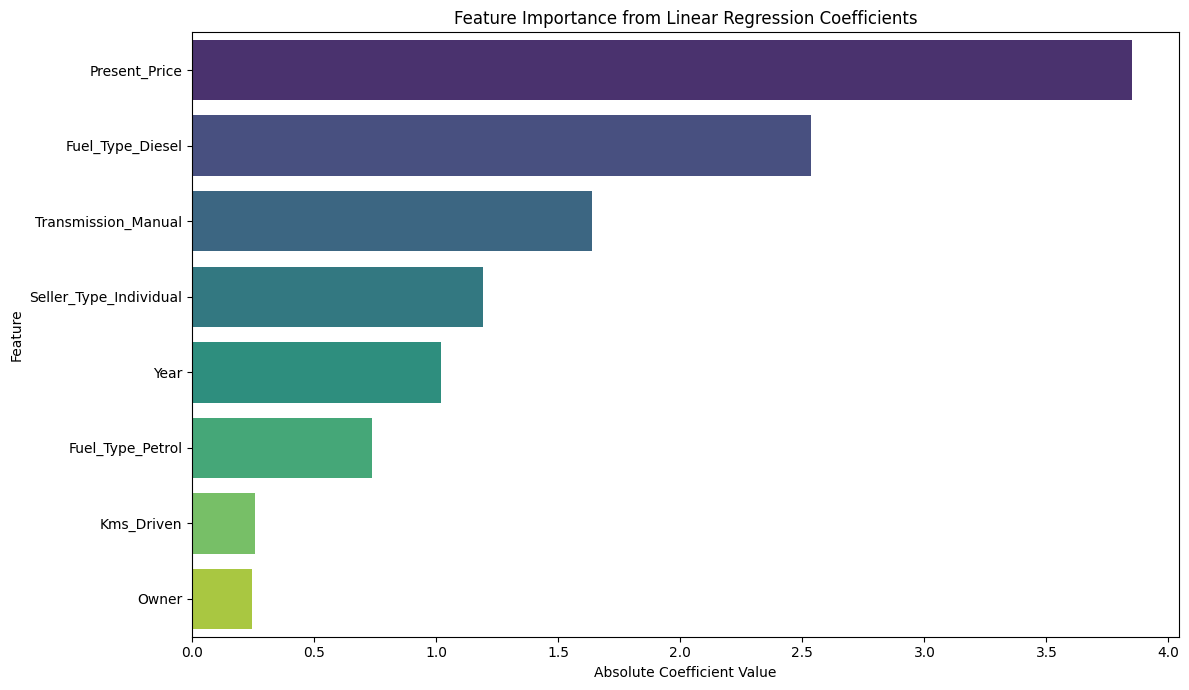

In [ ]:
# Get feature names from X_train (since X_train was used for training and contains scaled numerical features and encoded categorical features)
feature_names = X_train.columns

# Get the coefficients from the trained linear model
coefficients = linear_model.coef_

# Create a DataFrame to store feature names and their coefficients
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Calculate the absolute value of coefficients to determine importance magnitude
feature_importance['Absolute_Coefficient'] = np.abs(feature_importance['Coefficient'])

# Sort features by absolute coefficient in descending order
feature_importance = feature_importance.sort_values(by='Absolute_Coefficient', ascending=False)

print("Feature Importances (sorted by absolute coefficient):")
display(feature_importance)

# Visualize feature importance
plt.figure(figsize=(12, 7))
sns.barplot(x='Absolute_Coefficient', y='Feature', data=feature_importance, palette='viridis')
plt.title('Feature Importance from Linear Regression Coefficients')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 7. Insights

### What factors most influence car price?
Based on the Linear Regression model's coefficients (feature importance):

1.  **Present_Price**: This is by far the most influential factor, showing a strong positive correlation with `Selling_Price`. A higher current showroom price of the car directly translates to a higher selling price, which is intuitive.
2.  **Fuel_Type_Diesel**: Diesel cars command a significantly higher selling price compared to petrol or CNG variants. This is indicated by its high positive coefficient.
3.  **Transmission_Manual**: Manual transmission cars tend to have a negative impact on selling price compared to automatic cars (which is the baseline for the encoded feature). This suggests that automatic cars generally sell for more.
4.  **Seller_Type_Individual**: Cars sold by individuals tend to have a lower selling price compared to those sold by dealers. This could be due to perceived value, trust, or additional services offered by dealers.
5.  **Year**: Newer cars (higher `Year`) have a positive influence on the selling price, as expected due to depreciation.

Less influential factors, though still playing a role, include `Kms_Driven` and `Owner`.

### What surprised you in the data?

1.  **Relatively Low Impact of `Kms_Driven` and `Owner`**: While `Kms_Driven` and `Owner` do have a negative relationship with `Selling_Price` (more kilometers driven or more owners generally reduce the price), their absolute coefficients were surprisingly lower compared to `Present_Price` or `Fuel_Type`. This suggests that for this dataset, factors like the car's original value and fuel type have a more dominant linear impact on price than age or mileage (once `Year` and `Present_Price` are accounted for).
2.  **Strong Delineation by `Fuel_Type` and `Seller_Type`**: The significant difference in selling prices based on `Fuel_Type` (especially Diesel) and `Seller_Type` (Dealer vs. Individual) was quite pronounced. This highlights how these categorical attributes strongly segment the market and buyer perceptions.
3.  **Data Cleanliness**: The dataset was remarkably clean with no missing values, which is often not the case in real-world scenarios. This simplified the preprocessing step considerably.

### Predicting Selling Prices for Sample Cars

In [ ]:
# Create sample car data for prediction
sample_cars_data = {
    'Car_Name': ['New Sedan A', 'Used SUV B', 'Budget Hatch C', 'Luxury Sedan D', 'Electric Car E'],
    'Year': [2022, 2018, 2015, 2023, 2021],
    'Present_Price': [15.0, 10.0, 6.0, 25.0, 18.0],
    'Kms_Driven': [5000, 45000, 70000, 1000, 20000],
    'Fuel_Type': ['Petrol', 'Diesel', 'Petrol', 'Diesel', 'Petrol'], # Assuming 'Petrol' for electric, or a new category if applicable
    'Seller_Type': ['Dealer', 'Individual', 'Dealer', 'Dealer', 'Individual'],
    'Transmission': ['Automatic', 'Manual', 'Manual', 'Automatic', 'Automatic'],
    'Owner': [0, 1, 0, 0, 0]
}
sample_cars_df = pd.DataFrame(sample_cars_data)

print("Sample cars data created:")
display(sample_cars_df)

Next, we need to apply the same one-hot encoding to the categorical features of the sample cars as was applied to the training data. This ensures consistency in the features fed to the model.

In [ ]:
# Apply one-hot encoding to sample_cars_df
sample_cars_encoded = pd.get_dummies(sample_cars_df, columns=categorical_features, drop_first=True)

# Drop 'Car_Name' as it's not a feature for the model
sample_cars_final = sample_cars_encoded.drop('Car_Name', axis=1, errors='ignore')

# Align columns with X_train (add missing columns, fill with 0, and reorder)
missing_cols = set(X_train.columns) - set(sample_cars_final.columns)
for c in missing_cols:
    sample_cars_final[c] = 0
# Ensure the order of columns is the same as in X_train
sample_cars_final = sample_cars_final[X_train.columns]

print("Sample cars data after one-hot encoding and column alignment:")
display(sample_cars_final.head())

Now, we will scale the numerical features of the sample car data using the `StandardScaler` that was fitted on the training data. This is a crucial step to ensure the new data is in the same scale as the data the model was trained on.

In [ ]:
(sample_cars_scaled.head())# Scale numerical features in sample_cars_final using the *fitted* scaler
sample_cars_scaled = sample_cars_final.copy()
sample_cars_scaled[numerical_cols_to_scale] = scaler.transform(sample_cars_final[numerical_cols_to_scale])

print("Sample cars data after numerical feature scaling:")
display

Finally, we will use the trained Linear Regression model to predict the selling prices for these preprocessed sample cars.

In [ ]:
predicted_selling_prices = linear_model.predict(sample_cars_scaled)

# Add predictions to the original sample_cars_df for easy viewing
sample_cars_df['Predicted_Selling_Price'] = predicted_selling_prices

print("Predicted selling prices for sample cars:")
display(sample_cars_df[['Car_Name', 'Present_Price', 'Predicted_Selling_Price']])